In [ ]:
#Question 0
x = [2,3,4,7,19,20,21,22]
y = [4,8,14,18,42,43,44,47]

import numpy as np

def calc_lin_regr_parms(x, y):
    x = np.array(x)
    y = np.array(y)

    x_mean = x.mean()
    y_mean = y.mean()
    #below: the n-1 cancels out
    b_1 = ((x - x_mean)*(y-y_mean)).sum()/((x - x_mean)**2).sum()
    b_0 = y_mean - x_mean*b_1
    return float(b_0), float(b_1)

print(calc_lin_regr_parms(x,y))

(2.826086956521742, 2.0141969831410824)


In [ ]:
#question 0
from sklearn.linear_model import LinearRegression

x = [2,3,4,7,19,20,21,22]
y = [4,8,14,18,42,43,44,47]

x = np.array(x)
y = np.array(y)

model = LinearRegression()
model.fit(x.reshape(-1, 1), y)

print(model.intercept_, model.coef_[0])

2.8260869565217455 2.014196983141082


In [ ]:
#question 1
import pandas as pd

kirb21_df = pd.read_csv("https://raw.githubusercontent.com/smart-stats/ds4bio_book/refs/heads/main/qbook/assets/kirby21.csv")
print(kirb21_df.head())

Tel_L = list(kirb21_df[kirb21_df['roi'] == 'Telencephalon_L']['volume'])
Tel_R = list(kirb21_df[kirb21_df['roi'] == 'Telencephalon_R']['volume'])

print("Tel left as predictor, Tel right as outcome, (Beta0, Beta1): ",calc_lin_regr_parms(Tel_L,Tel_R))
print("Tel right as predictor, Tel left as outcome, (Beta0, Beta1): ",calc_lin_regr_parms(Tel_R,Tel_L))


   Unnamed: 0   id              roi  volume
0           1  127  Telencephalon_L  531111
1           2  127  Telencephalon_R  543404
2           3  127   Diencephalon_L    9683
3           4  127   Diencephalon_R    9678
4           5  127    Mesencephalon   10268
Tel left as predictor, Tel right as outcome, (Beta0, Beta1):  (-13875.944799423742, 1.044241539832241)
Tel right as predictor, Tel left as outcome, (Beta0, Beta1):  (17150.431045804115, 0.9500552111008128)


<Axes: xlabel='Telencephalon_L', ylabel='Telencephalon_R'>

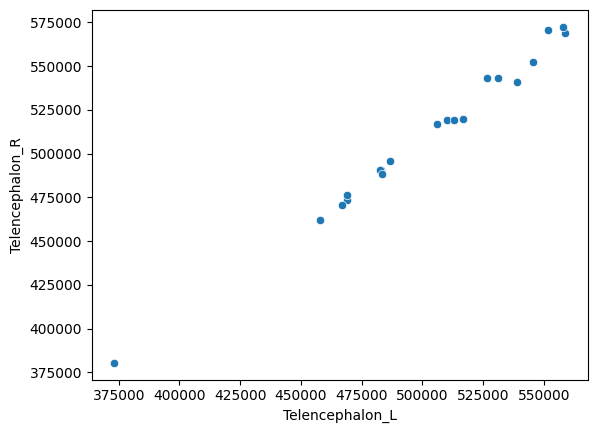

In [ ]:
#question 1
import seaborn as sns

tel_pivot = kirb21_df.pivot(index = 'id', columns = 'roi', values = 'volume')

sns.scatterplot(x = 'Telencephalon_L', y = 'Telencephalon_R', data = tel_pivot)


#question 2
if X is now c*X, where c is a positive constant, then:

Beta_1_hat_new = Cor(c*X,Y)*SD(Y)/SD(c*X)
            = Cor(X,Y)*SD(Y)/[c*SD(X)]   [since the c's cancel out when cor(c*X,Y) is written out using covariance and dividing by SD(X) and SD(Y)]
            = Beta_1_hat/c or B/c 


#question 3

If X is a binary variable of 0 or 1, then:

for X = 0, Y_hat = Beta_0 + 0*Beta_1 = Beta_0
for X = 1, Y_hat = Beta_0 + 1*Beta_1 = Beta_0 + Beta_1

For X = 0, all of the predictions (Y_hat) share the same value and it's a constant (beta_0)
For X = 1, all of the predictions (Y_hat) share the same value and it's a constant (beta_0 + beta_1)

For a set of numbers to minimize the least squared errors around a constant, we'd set the constant to be the mean of the set of numbers. So for X=0, Y_hat or beta_0 is the group mean for when X = 0 and for X = 1, Y_hat or beta_0+ beta_1 is the group mean for when X = 1.


#question 4

Given X' = X/SD(X) and Y' = Y/SD(Y), what is the new slope of the regression coefficient (in terms of X and Y) for X' predicting Y' and vice versa.

We know SD(X') = SD(X)/SD(X) = 1 and SD(Y') = SD(Y)/SD(Y) = 1

Beta_1_hat_prime[Y' predicting X'] = Cor(X',Y')*SD(X')/SD(Y') = Cor(X/SD(X), Y/SD(Y))*1/1 
        = Cor(X,Y) since 1/SD(X) and 1/SD(Y) are just positive constants and don't affect correlation as seen in question 2

Beta_1_hat_prime[X' predicting Y'] = Cor(X','Y')*SD(Y')/SD(X') = Cor(X/SD(X), Y/SD(Y))*1/1 
        = Cor(X,Y) since 1/SD(X) and 1/SD(Y) are just positive constants and don't affect correlation as seen in question 2 and the idea: Correlation is unchanged because scaling cancels out
